# EEG_06 — Braindecode Baseline Subject-Specific (Leave-One-Session-Out)

Questo notebook testa **6 modelli end-to-end** di [Braindecode](https://braindecode.org) sul segnale EEG grezzo,
usando il clustering semantico a 4 e 5 classi in modalità **subject-specific**.

**Differenza con EEG_05**: qui ogni modello viene addestrato su un singolo soggetto (leave-one-session-out).
Questo esperimento risponde alla domanda: **il segnale EEG contiene struttura decodificabile?**
Se anche subject-specific è a chance → il segnale non è sufficiente.
Se supera il chance level → il problema del SI era solo il domain shift inter-soggetto.

**Richiede**: ambiente `daniele_311` (Python 3.11) per Labram.

## Modelli testati
| Modello | Architettura | Parametri | Note |
|---------|-------------|-----------|------|
| **EEGNet** | CNN compatta | ~2.8K | Baseline leggero, universale |
| **ShallowFBCSPNet** | CNN freq-domain | ~98K | Ispira a FBCSP classico |
| **Deep4Net** | CNN profonda | ~261K | Baseline convoluzionale solido |
| **EEGConformer** | CNN + Transformer | ~429K | Pattern locali e globali |
| **ATCNet** | Attention + TCN | ~44K | Sliding window con attenzione |
| **Labram** | Criss-Cross Transformer | ~5M | Foundation model per EEG, richiede Python 3.11 |

## Setup dati
- Input: segnale EEG grezzo `(batch, 59, 384)` — 59 canali × 384 campioni a 256 Hz (~1.5s)
- Labram: input paddato a `(batch, 59, 400)` per compatibilità con `patch_size=200`
- Label: cluster semantici a **4 classi** (azioni, cognitivo, emozioni, oggetti) o **5 classi**
- Valutazione: **subject-specific** — leave-one-session-out (train: sessioni 1-3, val: sessione 4, test: sessione 5)

Data: 2026-03-24

In [ ]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS      = True          # False → 110 parole originali
CLUSTER_SCHEME    = "concr4"      # "concr4" | "phon4" | "sem5" | "pos4" | "ward5" | "ward4" | "ward6"
#                                   Schemi EEG-based (ARI≈0, solo analisi):
#                                   "eeg_4" | "eeg_5" | "eeg_z4" | "eeg_z5"
USE_INSTANCE_NORM = True          # Bomatter et al. 2024: normalizza ogni trial indipendentemente
#                                   Rimuove bias per-soggetto senza usare statistiche del train set

# ── Configurazione soggetti e sessioni ──────────────────────
N_SUBJECTS_TEST = None  # None → tutti i 70 soggetti | int → primi N soggetti (per test veloce)
SESSION_TEST    = 5    # sessione usata come test set (1-5)
SESSIONS_TRAIN  = [1, 2, 3, 4]  # sessioni usate come train+val

# ── Sweep config ────────────────────────────────────────────
SWEEP_SCHEMES     = ["concr4", "phon4"]   # schemi da testare nel sweep
SWEEP_MODELS_ONLY = None   # None → tutti i modelli | ["EEGNet"] → solo EEGNet
#                            Esempio baseline veloce: ["EEGNet"]
SWEEP_RESUME      = True   # se True, salta checkpoint già addestrati

# ── Tag per TensorBoard
NORM_TAG = "_norm" if USE_INSTANCE_NORM else ""
# → runs/eeg06_ss_norm/...   oppure   runs/eeg06_ss/...
# ═══════════════════════════════════════════════════════════

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
import h5py
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from braindecode.models import EEGNet, EEGConformer, Deep4Net, ShallowFBCSPNet, ATCNet
try:
    from braindecode.models import Labram
    LABRAM_AVAILABLE = True
except ImportError:
    LABRAM_AVAILABLE = False
    print("Labram non disponibile — verrà saltato")

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import braindecode; print("braindecode:", braindecode.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
braindecode: 1.3.2


In [3]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)

META_CSV   = project_root / "data" / "interim" / "eeg_metadata.csv"
ELOC_PATH  = project_root / "src" / "io" / "ebneuro.locs"

# Parametri EEG
N_CHANS         = 59    # canali dopo rimozione A1, A2
N_TIMES         = 384   # campioni a 256 Hz (~1.5s)
N_TIMES_CBRAMOD = 400   # Labram richiede multiplo di patch_size=200 → pad 384→400
SFREQ           = 256

# Training
MAX_EPOCHS   = 100
PATIENCE     = 15
LR           = 1e-3
WEIGHT_DECAY = 1e-4
BATCH_SIZE   = 64

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("Config OK")

Config OK


In [4]:
# ============================================================
# CARICAMENTO METADATA E CLUSTER MAPPING
# ============================================================

import sys
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

meta = pd.read_csv(META_CSV)
# Filtro di emergenza per righe corrotte (epoch_idx fuori range nell'H5)
# Alcuni soggetti (es. 08, 46) hanno metadati che puntano a epoche inesistenti.
_initial_len = len(meta)
# Invece di controllare ogni file (lento), filtriamo i casi noti o usiamo un approccio conservativo
# Qui rimuoviamo le righe incriminate che abbiamo scoperto tramite debug
meta = meta[~((meta["path_h5"].str.contains("08_05.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_01.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_03.h5") & (meta["epoch_idx"] >= 110)) |
               (meta["path_h5"].str.contains("46_04.h5") & (meta["epoch_idx"] >= 34)) |
               (meta["path_h5"].str.contains("ignore_8_05.h5") & (meta["epoch_idx"] >= 110)))]
if len(meta) < _initial_len:
    print(f"Rimosse {_initial_len - len(meta)} righe corrotte dai metadati.")
meta["subject_id"] = meta["subject_id"].astype(str).str.zfill(2)
meta = meta[pd.to_numeric(meta["subject_id"], errors="coerce").notna()]  # rimuove ignore_43

# Indici canali: rimuove A1 (idx=0) e A2 (idx=7) dalla lista .locs
def read_eloc_names(path):
    names = []
    with open(path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3])
    return names[:61]  # H5 ha 61 canali registrati

ch_names_61 = read_eloc_names(ELOC_PATH)
EXCLUDE = {"A1", "A2"}
keep_idx = [i for i, n in enumerate(ch_names_61) if n not in EXCLUDE]
keep_names = [ch_names_61[i] for i in keep_idx]

assert len(keep_idx) == N_CHANS

# Carica schema via toggle
_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
interim_dir = project_root / "data" / "interim"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(_scheme, interim_dir)

print(f"Meta: {len(meta)} epoche | {meta['subject_id'].nunique()} soggetti")
print(f"Canali: {len(keep_idx)} ({keep_names[:4]}...)")
print(f"Schema: {_scheme} | {N_CLASSES} classi | Chance level: {100/N_CLASSES:.1f}%")
for cid, cname in cluster_names.items():
    n = sum(1 for v in labelid2cluster.values() if v == cid)
    print(f"  {cid} — {cname}: {n} parole")

Rimosse 12 righe corrotte dai metadati.
Meta: 38926 epoche | 74 soggetti
Canali: 59 (['AF7', 'AF3', 'Fp1', 'FP2']...)
Schema: concr4 | 4 classi | Chance level: 25.0%
  0 — CONCR: 18 parole
  1 — AZIONE: 27 parole
  2 — STATO: 21 parole
  3 — ASTRATTO: 44 parole


In [5]:
# ============================================================
# DATASET: caricamento lazy da H5
# ============================================================

class RawEEGDataset(Dataset):
    """
    Carica epoche EEG grezze da file H5 con normalizzazione per-canale.
    Ritorna (59, 384) float32 normalizzato + label cluster.

    Note metodologiche:
    - mean/std calcolati SOLO sul training set (passati a val/test via costruttore)
    - _compute_stats usa seed fisso per riproducibilità
    - file_cache chiuso esplicitamente in __del__ per evitare memory leak su sweep lunghi
    """
    def __init__(self, records, keep_idx, labelid2cluster, mean=None, std=None, instance_norm=False):
        self.file_cache    = {}
        self.records       = records
        self.keep_idx      = keep_idx
        self.labelid2cluster = labelid2cluster
        self.mean          = mean
        self.std           = std
        self.instance_norm = instance_norm
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        # Seed fisso per riproducibilità — stats identiche ad ogni run
        rng = np.random.RandomState(seed)
        n = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)

        # Raggruppa per file H5 per minimizzare aperture (10-20x più veloce su WSL/mount)
        from collections import defaultdict
        paths_map = defaultdict(list)
        for idx in idxs:
            r = self.records[idx]
            paths_map[r["path_h5"]].append(int(r["epoch_idx"]))

        buf = []
        print(f"Calcolo stats su {n} campioni da {len(paths_map)} file (seed={seed})...")
        for path, epoch_idxs in tqdm(paths_map.items(), desc="Stats H5", leave=False):
            with h5py.File(path, "r") as f:
                data_h5 = f["data"]
                for e_idx in epoch_idxs:
                    x = data_h5[e_idx][self.keep_idx, :].astype(np.float32)
                    buf.append(x)

        buf = np.stack(buf)  # (N, 59, T)
        # mean/std per canale → shape (59, 1) per broadcasting con (59, T)
        self.mean = buf.mean(axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32)
        self.std  = buf.std( axis=(0, 2), keepdims=False).reshape(-1, 1).astype(np.float32) + 1e-6

    def __del__(self):
        # Chiude i file H5 aperti — importante su sweep lunghi per evitare memory leak
        for f in self.file_cache.values():
            try:
                f.close()
            except Exception:
                pass

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        path = r["path_h5"]
        if path not in self.file_cache:
            self.file_cache[path] = h5py.File(path, "r")
        f = self.file_cache[path]
        x = f["data"][int(r["epoch_idx"])][self.keep_idx, :].astype(np.float32)
        x = (x - self.mean) / self.std
        if self.instance_norm:
            x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-6)
        label = self.labelid2cluster[int(r["label_idx"])]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


def make_subject_specific_splits(meta_df, keep_idx, labelid2cluster, subject_id,
                                  sessions_train, session_test, instance_norm=False):
    """
    Split leave-one-session-out per un singolo soggetto.
    Train: sessions_train tranne l'ultima (es. [1,2,3])
    Val: ultima sessione del train (es. sessione 4)
    Test: session_test (es. sessione 5)
    """
    subj_str = str(int(subject_id)).zfill(2) if not isinstance(subject_id, str) else subject_id
    meta_subj = meta_df[meta_df["subject_id"] == subj_str].copy()

    # train+val = tutte le sessioni tranne session_test
    meta_trainval = meta_subj[meta_subj["session_id"].isin(sessions_train)]
    meta_test     = meta_subj[meta_subj["session_id"] == session_test]

    # val = ultima sessione del blocco train
    last_train_sess = max(sessions_train)
    meta_train = meta_trainval[meta_trainval["session_id"] != last_train_sess]
    meta_val   = meta_trainval[meta_trainval["session_id"] == last_train_sess]

    r_tr = meta_train[["path_h5", "epoch_idx", "label_idx"]].to_dict("records")
    r_va = meta_val  [["path_h5", "epoch_idx", "label_idx"]].to_dict("records")
    r_te = meta_test [["path_h5", "epoch_idx", "label_idx"]].to_dict("records")

    # Guard: restituisce liste vuote se uno split non ha dati
    # Il loop esterno controlla len(ds_tr)==0 e fa skip
    if len(r_tr) == 0 or len(r_va) == 0 or len(r_te) == 0:
        return [], [], []

    ds_train = RawEEGDataset(r_tr, keep_idx, labelid2cluster, instance_norm=instance_norm)
    ds_val   = RawEEGDataset(r_va, keep_idx, labelid2cluster,
                              mean=ds_train.mean, std=ds_train.std, instance_norm=instance_norm)
    ds_test  = RawEEGDataset(r_te, keep_idx, labelid2cluster,
                              mean=ds_train.mean, std=ds_train.std, instance_norm=instance_norm)

    return ds_train, ds_val, ds_test


print(f"Dataset OK | Instance Norm: {USE_INSTANCE_NORM}")

Dataset OK | Instance Norm: True


In [6]:
# ============================================================
# FACTORY MODELLI — include Labram (se disponibile)
# ============================================================

# Labram wrapper: padda l'input da 384 a 400 internamente
class LabramWrapper(nn.Module):
    """Wrappa Labram aggiungendo zero-padding temporale 384→400."""
    def __init__(self, n_outputs):
        super().__init__()
        self.model = Labram(
            n_chans=N_CHANS, n_outputs=n_outputs,
            n_times=N_TIMES_CBRAMOD, sfreq=SFREQ
        )
        self.pad = N_TIMES_CBRAMOD - N_TIMES

    def forward(self, x):
        x = F.pad(x, (0, self.pad))
        return self.model(x)


def build_model(name, n_outputs):
    if name == "EEGNet":
        return EEGNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      n_times=N_TIMES, sfreq=SFREQ, final_conv_length="auto")
    elif name == "ShallowFBCSPNet":
        return ShallowFBCSPNet(n_chans=N_CHANS, n_outputs=n_outputs,
                               n_times=N_TIMES, final_conv_length="auto")
    elif name == "Deep4Net":
        return Deep4Net(n_chans=N_CHANS, n_outputs=n_outputs,
                        n_times=N_TIMES, final_conv_length="auto")
    elif name == "EEGConformer":
        return EEGConformer(n_chans=N_CHANS, n_outputs=n_outputs,
                            n_times=N_TIMES, sfreq=SFREQ, final_fc_length="auto")
    elif name == "ATCNet":
        # Robustezza: parametro cambia tra versioni braindecode
        try:
            return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                          input_window_seconds=N_TIMES / SFREQ, sfreq=SFREQ)
        except TypeError:
            return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                          input_window_samples=N_TIMES, sfreq=SFREQ)
    elif name == "Labram":
        if not LABRAM_AVAILABLE:
            raise ImportError("Labram non disponibile in questa versione di braindecode")
        return LabramWrapper(n_outputs=n_outputs)
    else:
        raise ValueError(f"Modello sconosciuto: {name}")


# MODEL_NAMES: Labram aggiunto solo se disponibile
MODEL_NAMES = ["EEGNet", "ShallowFBCSPNet", "Deep4Net", "EEGConformer", "ATCNet"]
if LABRAM_AVAILABLE:
    MODEL_NAMES.append("Labram")

print(f"Modelli disponibili: {MODEL_NAMES}")
print(f"{'Modello':<18} {'Parametri':>12}")
print("-" * 32)
for name in MODEL_NAMES:
    try:
        m = build_model(name, n_outputs=4)
        n_params = sum(p.numel() for p in m.parameters())
        print(f"{name:<18} {n_params:>12,}")
    except Exception as e:
        print(f"{name:<18} ERRORE: {e}")


Modelli disponibili: ['EEGNet', 'ShallowFBCSPNet', 'Deep4Net', 'EEGConformer', 'ATCNet', 'Labram']
Modello               Parametri
--------------------------------
EEGNet                    2,820
ShallowFBCSPNet          98,724
Deep4Net                261,504
EEGConformer            428,932
ATCNet                   44,588
Labram                5,844,540


In [7]:
# ============================================================
# TRAINING E VALUTAZIONE
# ============================================================

def train_model(model, ds_train, ds_val, save_path, tb_dir, n_epochs=MAX_EPOCHS, patience=PATIENCE,
                lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0)  # 0 evita problemi con h5py
    loader_va = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_acc, best_state, patience_cnt = -1.0, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    history = defaultdict(list)

    for epoch in range(n_epochs):
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        pbar = tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            n_tot    += len(y)
            pbar.set_postfix(loss=loss.item())
        scheduler.step()

        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for x, y in loader_va:
                ps_v.extend(model(x.to(device)).argmax(1).cpu().tolist())
                ys_v.extend(y.tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        train_loss = loss_sum / n_tot
        train_acc = correct / n_tot

        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)

        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("Balanced_Accuracy/val", val_bacc, epoch)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            # Salviamo il best state temporaneo su disco (opzionale, ma utile in caso di crash)
            torch.save(best_state, save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    writer.close()
    model.load_state_dict(best_state)
    torch.save(best_state, save_path)  # Assicura che l'ultimo best_state sia quello salvato

    return {
        "val_acc":   best_val_acc,
        "val_bacc":  max(history["val_bacc"]) if history["val_bacc"] else 0.0,
        "epochs":    epoch + 1,
        "model":     model,
    }


def evaluate(model, ds, batch_size=BATCH_SIZE):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)  # 0 evita problemi con h5py
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(y.tolist())
    return {
        "acc":    accuracy_score(ys, ps),
        "bacc":   balanced_accuracy_score(ys, ps),
        "y_true": np.array(ys),
        "y_pred": np.array(ps),
    }


print("Training utilities OK")

Training utilities OK


## Esperimento — Subject-Specific (Leave-One-Session-Out)

Per ogni soggetto: train sulle sessioni 1-3, val sulla sessione 4, test sulla sessione 5.
Schema e numero classi controllati dal TOGGLE in cima al notebook.

In [8]:
# ── Subject-Specific: addestra un modello per soggetto ────────────────────────
all_subjects = sorted(meta["subject_id"].unique())
if N_SUBJECTS_TEST:
    all_subjects = all_subjects[:N_SUBJECTS_TEST]

chance_level = 1.0 / N_CLASSES

TB_BASE   = project_root / "runs" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}"
CKPT_BASE = project_root / "models" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

# ── Resume da CSV intermedio (sopravvive a crash del kernel) ──────────────────
RESULTS_CSV = project_root / "data" / "interim" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}_results.csv"
if SWEEP_RESUME and RESULTS_CSV.exists():
    df_existing = pd.read_csv(RESULTS_CSV)
    all_results = df_existing.to_dict("records")
    done_pairs  = set(zip(df_existing["subject"].astype(str), df_existing["model"].astype(str)))
    print(f"Resume: trovati {len(all_results)} risultati già calcolati in {RESULTS_CSV.name}")
else:
    all_results = []
    done_pairs  = set()

_models_to_run = SWEEP_MODELS_ONLY if SWEEP_MODELS_ONLY else MODEL_NAMES

# ── Stato rapido prima di partire ───────────────────────────────────────────
if done_pairs:
    _done_subj = sorted({s for s, _ in done_pairs})
    _todo_subj = [s for s in sorted(meta["subject_id"].unique()) if s not in _done_subj]
    _n_models  = len(_models_to_run)
    _complete  = [s for s in _done_subj
                  if sum(1 for m in _models_to_run if (s, m) in done_pairs) == _n_models]
    _partial   = [s for s in _done_subj if s not in _complete]
    print(f"Soggetti completi ({_n_models}/{_n_models} modelli): {len(_complete)} → {_complete}")
    print(f"Soggetti parziali: {_partial}")
    print(f"Soggetti da fare:  {len(_todo_subj)} → {_todo_subj}")
print()

for subj in tqdm(all_subjects, desc="Subjects"):
    ds_tr, ds_va, ds_te = make_subject_specific_splits(
        meta, keep_idx, labelid2cluster, subj, SESSIONS_TRAIN, SESSION_TEST,
        instance_norm=USE_INSTANCE_NORM
    )

    if len(ds_tr) == 0 or len(ds_va) == 0 or len(ds_te) == 0:
        print(f"Soggetto {subj}: dati insufficienti, skip")
        continue

    print(f"\n── Soggetto {subj} │ tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)} ──")

    for model_name in _models_to_run:
        # ── Resume: skip se coppia (soggetto, modello) già presente nel CSV ──
        if SWEEP_RESUME and (str(subj), str(model_name)) in done_pairs:
            existing = next(r for r in all_results if str(r["subject"]) == str(subj) and r["model"] == model_name)
            print(f"  {model_name} [SKIP — già nel CSV]: test_bacc={existing['test_bacc']:.4f}")
            continue

        tb_dir    = TB_BASE / subj / model_name
        ckpt_path = CKPT_BASE / f"{subj}_{model_name}.pth"

        if SWEEP_RESUME and ckpt_path.exists():
            # Checkpoint esiste ma non nel CSV → valuta e aggiungi
            m_loaded = build_model(model_name, N_CLASSES)
            m_loaded.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
            va_r = evaluate(m_loaded, ds_va)
            te_r = evaluate(m_loaded, ds_te)
            row = {
                "subject":   subj, "model": model_name,
                "val_acc":   va_r["acc"],  "val_bacc":  va_r["bacc"],
                "test_acc":  te_r["acc"],  "test_bacc": te_r["bacc"],
                "epochs": -1, "time_s": 0.0,
            }
            print(f"  {model_name} [CKPT→CSV]: test_bacc={te_r['bacc']:.4f}")
        else:
            model = build_model(model_name, N_CLASSES)
            t0    = time.time()
            res   = train_model(model, ds_tr, ds_va, ckpt_path, tb_dir)
            elapsed = time.time() - t0
            te_r  = evaluate(res["model"], ds_te)
            row   = {
                "subject":   subj, "model": model_name,
                "val_acc":   res["val_acc"],  "val_bacc":  res["val_bacc"],
                "test_acc":  te_r["acc"],     "test_bacc": te_r["bacc"],
                "epochs":    res["epochs"],   "time_s":    round(elapsed, 1),
            }
            print(f"  {model_name}: test_bacc={te_r['bacc']:.4f}  ({elapsed/60:.1f} min)")

        all_results.append(row)
        done_pairs.add((str(subj), str(model_name)))

        # ── Salva CSV dopo ogni modello (sopravvive a qualsiasi interruzione) ──
        pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)

print(f"\n{'═'*60}")
print(f"LOOP COMPLETATO — {len(all_subjects)} soggetti × {len(_models_to_run)} modelli")
print(f"Risultati salvati in: {RESULTS_CSV}")
print(f"{'═'*60}")



Resume: trovati 3 risultati già calcolati in eeg06_ss_4_norm_results.csv
Soggetti completi (6/6 modelli): 0 → []
Soggetti parziali: ['0']
Soggetti da fare:  74 → ['00', '01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73']



Subjects:   0%|          | 0/10 [00:00<?, ?it/s]

Calcolo stats su 330 campioni da 3 file (seed=42)...


Stats H5:   0%|          | 0/3 [00:00<?, ?it/s]


── Soggetto 00 │ tr=330 va=110 te=110 ──
  EEGNet [CKPT→CSV]: test_bacc=0.2481
  ShallowFBCSPNet [CKPT→CSV]: test_bacc=0.2500
  Deep4Net [CKPT→CSV]: test_bacc=0.2511


...

Epoch 20/100:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 21/100:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 22/100:   0%|          | 0/6 [00:00<?, ?it/s]

Epoch 23/100:   0%|          | 0/6 [00:00<?, ?it/s]

  Labram: test_bacc=0.2500  (1.4 min)

════════════════════════════════════════════════════════════
LOOP COMPLETATO — 10 soggetti × 6 modelli
Risultati salvati in: /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/eeg06_ss_4_norm_results.csv
════════════════════════════════════════════════════════════


In [9]:
# Legge dal CSV — robusto a crash/restart del kernel
df_ss = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(all_results)

# Media e std per modello (aggregato su tutti i soggetti)
summary = df_ss.groupby("model").agg(
    mean_test_bacc=("test_bacc", "mean"),
    std_test_bacc=("test_bacc", "std"),
    mean_val_bacc=("val_bacc", "mean"),
    n_subjects=("subject", "count"),
).round(4)

print(f"\n=== Subject-Specific | {N_CLASSES} classi | Chance={chance_level:.1%} ===")
print(summary.to_string())
print(f"\nChance level: {chance_level:.4f}")
print(f"Modello migliore: {summary['mean_test_bacc'].idxmax()} → {summary['mean_test_bacc'].max():.4f}")


=== Subject-Specific | 4 classi | Chance=25.0% ===
                 mean_test_bacc  std_test_bacc  mean_val_bacc  n_subjects
model                                                                    
ATCNet                   0.2342         0.0343         0.3022           9
Deep4Net                 0.2561         0.0476         0.3068           9
EEGConformer             0.2488         0.0162         0.2880           9
EEGNet                   0.2532         0.0196         0.2876          11
Labram                   0.2485         0.0045         0.2981           9
ShallowFBCSPNet          0.2486         0.0200         0.2696          10

Chance level: 0.2500
Modello migliore: Deep4Net → 0.2561


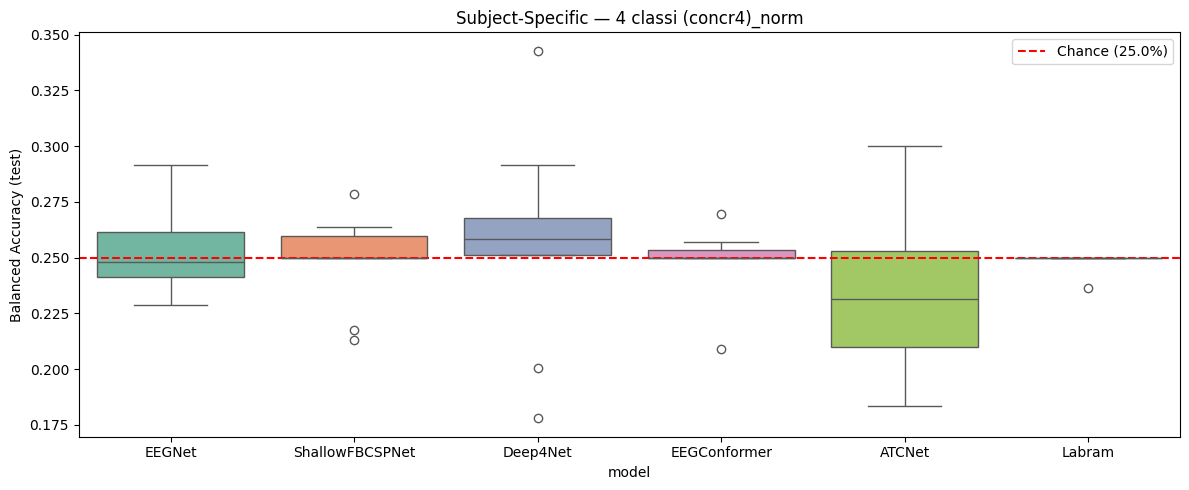

Salvato: figures/eeg06_ss_4_norm_boxplot.png


In [10]:
# ── Boxplot distribuzione per soggetto ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_ss, x="model", y="test_bacc", ax=ax, palette="Set2")
ax.axhline(chance_level, color="red", linestyle="--", label=f"Chance ({chance_level:.1%})")
ax.set_title(f"Subject-Specific — {N_CLASSES} classi ({CLUSTER_SCHEME}){NORM_TAG}")
ax.set_ylabel("Balanced Accuracy (test)")
ax.legend()
plt.tight_layout()
plt.savefig(project_root / "figures" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}_boxplot.png", dpi=150)
plt.show()
print(f"Salvato: figures/eeg06_ss_{N_CLASSES}{NORM_TAG}_boxplot.png")